In [2]:
import pandas as pd

data = [
    # =========================
    # 🔴 BASELINE (NO SVDD)
    # =========================
    ["KAN-AD (Baseline)", "None", "No SVDD", "SWaT", 0.7415, 0.7305, 0.8959, 0.6933],
    ["KAN-AD (Baseline)", "None", "No SVDD", "MSL",  0.4633, 0.5310, 0.6673, 0.3667],

    # =========================
    # 🟢 HYBRID MODELS (KAN + SVDD)
    # =========================

    # Fourier
    ["FourierKAN", "Attn", "SVDD", "SWaT", 0.9316, 0.9631, 0.9021, 0.9672],
    ["FourierKAN", "Attn", "SVDD", "MSL",  0.8477, 0.8017, 0.8993, 0.8533],
    ["FourierKAN", "NoAttn", "SVDD", "SWaT", 0.9200, 0.9833, 0.8643, 0.9456],
    ["FourierKAN", "NoAttn", "SVDD", "MSL",  0.8720, 0.9266, 0.8236, 0.9049],

    # RBF
    ["RBFKAN", "Attn", "SVDD", "SWaT", 0.9260, 0.9665, 0.8887, 0.9470],
    ["RBFKAN", "Attn", "SVDD", "MSL",  0.8684, 0.9007, 0.8382, 0.9059],
    ["RBFKAN", "NoAttn", "SVDD", "SWaT", 0.9445, 0.9782, 0.9131, 0.9308],
    ["RBFKAN", "NoAttn", "SVDD", "MSL",  0.9445, 0.9782, 0.9131, 0.9308],

    # Wavelet
    ["WaveletKAN", "Attn", "SVDD", "SWaT", 0.9508, 0.9352, 0.9669, 0.9810],
    ["WaveletKAN", "Attn", "SVDD", "MSL",  0.9242, 0.9158, 0.9327, 0.9047],
    ["WaveletKAN", "NoAttn", "SVDD", "SWaT", 0.9063, 0.8681, 0.9480, 0.9704],
    ["WaveletKAN", "NoAttn", "SVDD", "MSL",  0.7246, 0.7393, 0.7104, 0.6606],
]

df = pd.DataFrame(data, columns=[
    "Model", "Attention", "SVDD", "Dataset",
    "F1", "Precision", "Recall", "AUPRC"
])

df

,Model,Attention,SVDD,Dataset,F1,Precision,Recall,AUPRC
0,KAN-AD (Baseline),None,No SVDD,SWaT,0.7415,0.7305,0.8959,0.6933
1,KAN-AD (Baseline),None,No SVDD,MSL,0.4633,0.5310,0.6673,0.3667
2,FourierKAN,Attn,SVDD,SWaT,0.9316,0.9631,0.9021,0.9672
3,FourierKAN,Attn,SVDD,MSL,0.8477,0.8017,0.8993,0.8533
4,FourierKAN,NoAttn,SVDD,SWaT,0.9200,0.9833,0.8643,0.9456
5,FourierKAN,NoAttn,SVDD,MSL,0.8720,0.9266,0.8236,0.9049
6,RBFKAN,Attn,SVDD,SWaT,0.9260,0.9665,0.8887,0.9470
7,RBFKAN,Attn,SVDD,MSL,0.8684,0.9007,0.8382,0.9059
8,RBFKAN,NoAttn,SVDD,SWaT,0.9445,0.9782,0.9131,0.9308
9,RBFKAN,NoAttn,SVDD,MSL,0.9445,0.9782,0.9131,0.9308


In [3]:
df_swat = df[df["Dataset"] == "SWaT"].sort_values("F1", ascending=False)
df_msl  = df[df["Dataset"] == "MSL"].sort_values("F1", ascending=False)

print("=== SWaT ===")
display(df_swat)

print("=== MSL ===")
display(df_msl)

=== SWaT ===


,Model,Attention,SVDD,Dataset,F1,Precision,Recall,AUPRC
10,WaveletKAN,Attn,SVDD,SWaT,0.9508,0.9352,0.9669,0.9810
8,RBFKAN,NoAttn,SVDD,SWaT,0.9445,0.9782,0.9131,0.9308
2,FourierKAN,Attn,SVDD,SWaT,0.9316,0.9631,0.9021,0.9672
6,RBFKAN,Attn,SVDD,SWaT,0.9260,0.9665,0.8887,0.9470
4,FourierKAN,NoAttn,SVDD,SWaT,0.9200,0.9833,0.8643,0.9456
12,WaveletKAN,NoAttn,SVDD,SWaT,0.9063,0.8681,0.9480,0.9704
0,KAN-AD (Baseline),None,No SVDD,SWaT,0.7415,0.7305,0.8959,0.6933


=== MSL ===


,Model,Attention,SVDD,Dataset,F1,Precision,Recall,AUPRC
9,RBFKAN,NoAttn,SVDD,MSL,0.9445,0.9782,0.9131,0.9308
11,WaveletKAN,Attn,SVDD,MSL,0.9242,0.9158,0.9327,0.9047
5,FourierKAN,NoAttn,SVDD,MSL,0.8720,0.9266,0.8236,0.9049
7,RBFKAN,Attn,SVDD,MSL,0.8684,0.9007,0.8382,0.9059
3,FourierKAN,Attn,SVDD,MSL,0.8477,0.8017,0.8993,0.8533
13,WaveletKAN,NoAttn,SVDD,MSL,0.7246,0.7393,0.7104,0.6606
1,KAN-AD (Baseline),None,No SVDD,MSL,0.4633,0.5310,0.6673,0.3667


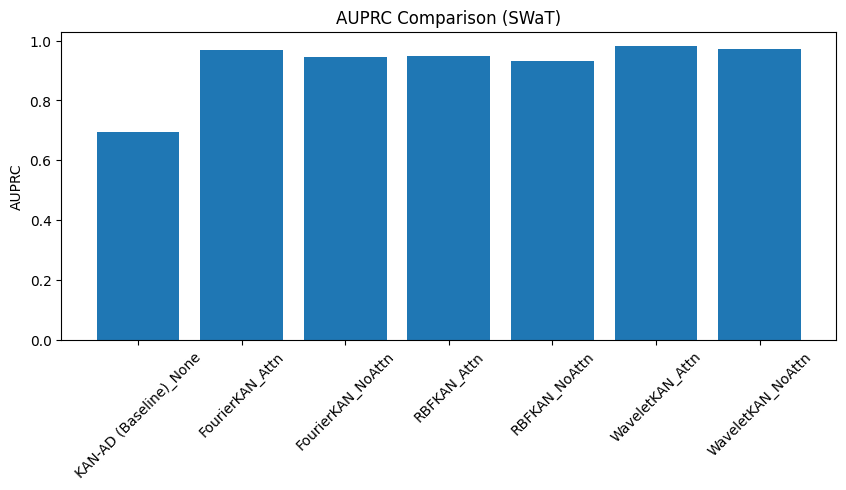

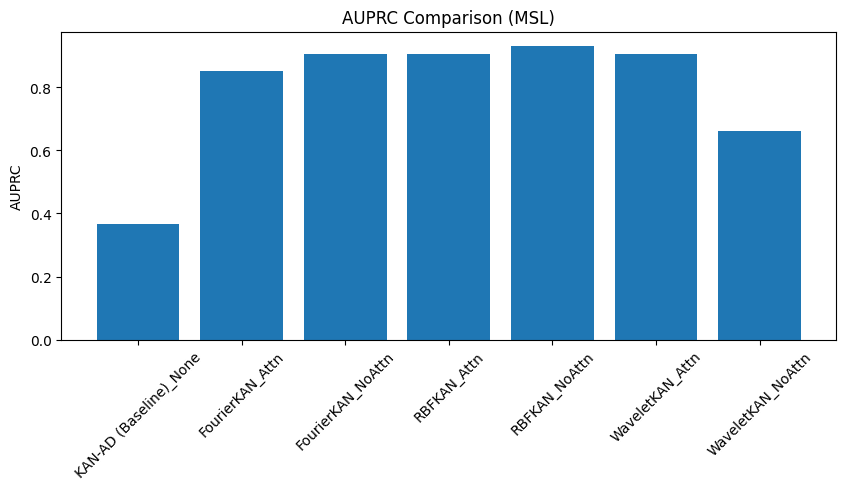

In [6]:
import matplotlib.pyplot as plt

for dataset in ["SWaT", "MSL"]:
    sub = df[df["Dataset"] == dataset]

    plt.figure(figsize=(10,4))
    plt.bar(sub["Model"] + "_" + sub["Attention"], sub["AUPRC"])
    plt.title(f"AUPRC Comparison ({dataset})")
    plt.xticks(rotation=45)
    plt.ylabel("AUPRC")
    plt.show()

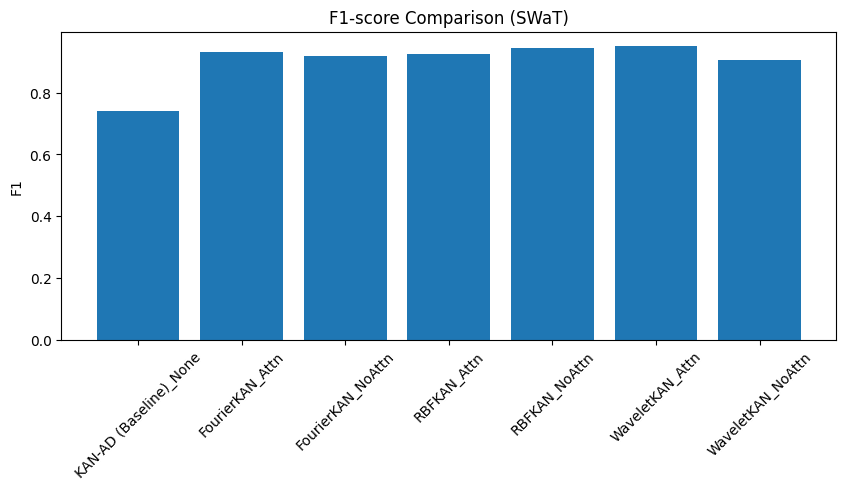

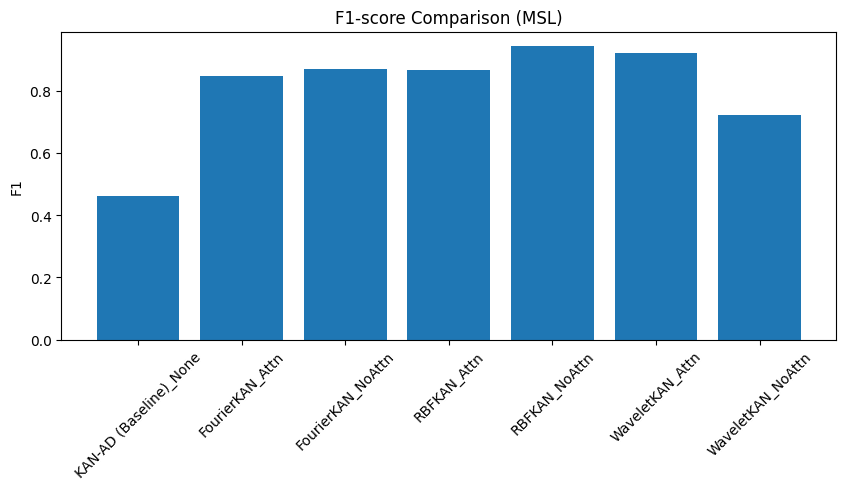

In [8]:
for dataset in ["SWaT", "MSL"]:
    sub = df[df["Dataset"] == dataset]

    plt.figure(figsize=(10,4))
    plt.bar(sub["Model"] + "_" + sub["Attention"], sub["F1"])
    plt.title(f"F1-score Comparison ({dataset})")
    plt.xticks(rotation=45)
    plt.ylabel("F1")
    plt.show()

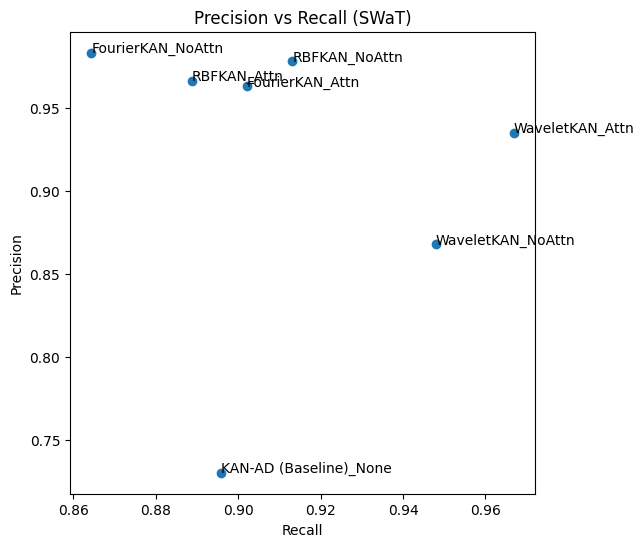

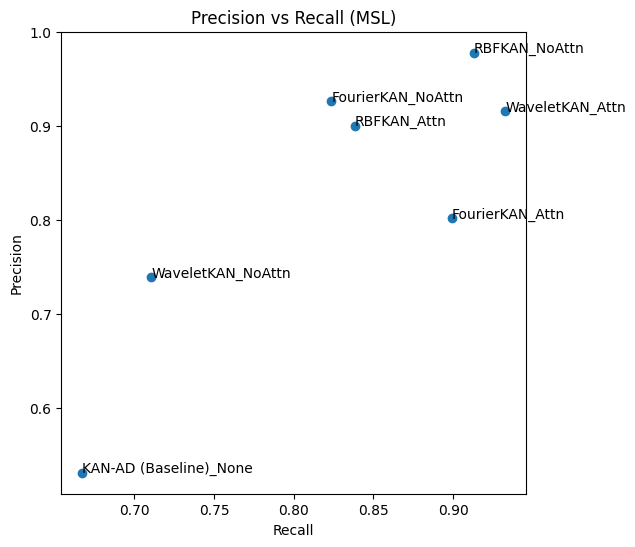

In [10]:
for dataset in ["SWaT", "MSL"]:
    sub = df[df["Dataset"] == dataset]

    plt.figure(figsize=(6,6))
    plt.scatter(sub["Recall"], sub["Precision"])

    for _, row in sub.iterrows():
        plt.text(row["Recall"], row["Precision"], row["Model"]+"_"+row["Attention"])

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision vs Recall ({dataset})")
    plt.show()

In [14]:
baseline_swat = df[(df["Model"]=="KAN-AD (Baseline)") & (df["Dataset"]=="SWaT")].iloc[0]
baseline_msl  = df[(df["Model"]=="KAN-AD (Baseline)") & (df["Dataset"]=="MSL")].iloc[0]

improvements = []

for _, row in df.iterrows():
    # skip baseline rows
    if row["Model"] == "KAN-AD (Baseline)":
        continue

    base = baseline_swat if row["Dataset"]=="SWaT" else baseline_msl

    improvements.append([
        row["Model"],
        row["Attention"],
        row["Dataset"],
        row["F1"] - base["F1"],
        row["AUPRC"] - base["AUPRC"]
    ])

imp_df = pd.DataFrame(improvements, columns=["Model","Attention","Dataset","ΔF1","ΔAUPRC"])

imp_df.sort_values(["Dataset","ΔF1"], ascending=False)

,Model,Attention,Dataset,ΔF1,ΔAUPRC
8,WaveletKAN,Attn,SWaT,0.2093,0.2877
6,RBFKAN,NoAttn,SWaT,0.2030,0.2375
0,FourierKAN,Attn,SWaT,0.1901,0.2739
4,RBFKAN,Attn,SWaT,0.1845,0.2537
2,FourierKAN,NoAttn,SWaT,0.1785,0.2523
10,WaveletKAN,NoAttn,SWaT,0.1648,0.2771
7,RBFKAN,NoAttn,MSL,0.4812,0.5641
9,WaveletKAN,Attn,MSL,0.4609,0.5380
3,FourierKAN,NoAttn,MSL,0.4087,0.5382
5,RBFKAN,Attn,MSL,0.4051,0.5392
